In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download from UCI or use this direct approach- i will use direct approach
df = pd.read_csv(r"C:\Users\emman\student-mat.csv", sep=';')

print(df.shape)        # (395, 33)
print(df.head())
print(df.info())
print(df.describe())


(395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data c

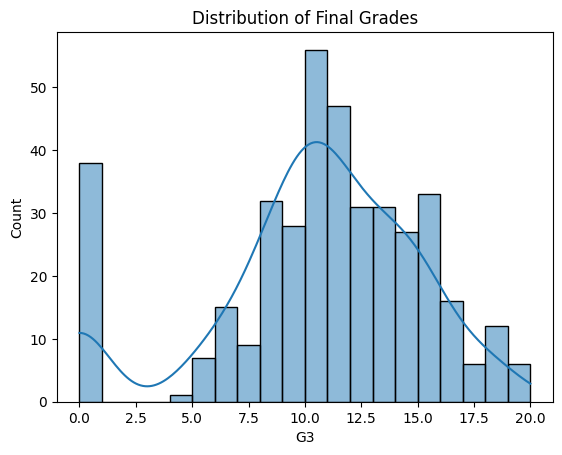

In [17]:
#EDA- Exploratory Data Aanalysis 
# Distribution of final grades
sns.histplot(df['G3'], bins=20, kde=True)
plt.title("Distribution of Final Grades")
plt.show()



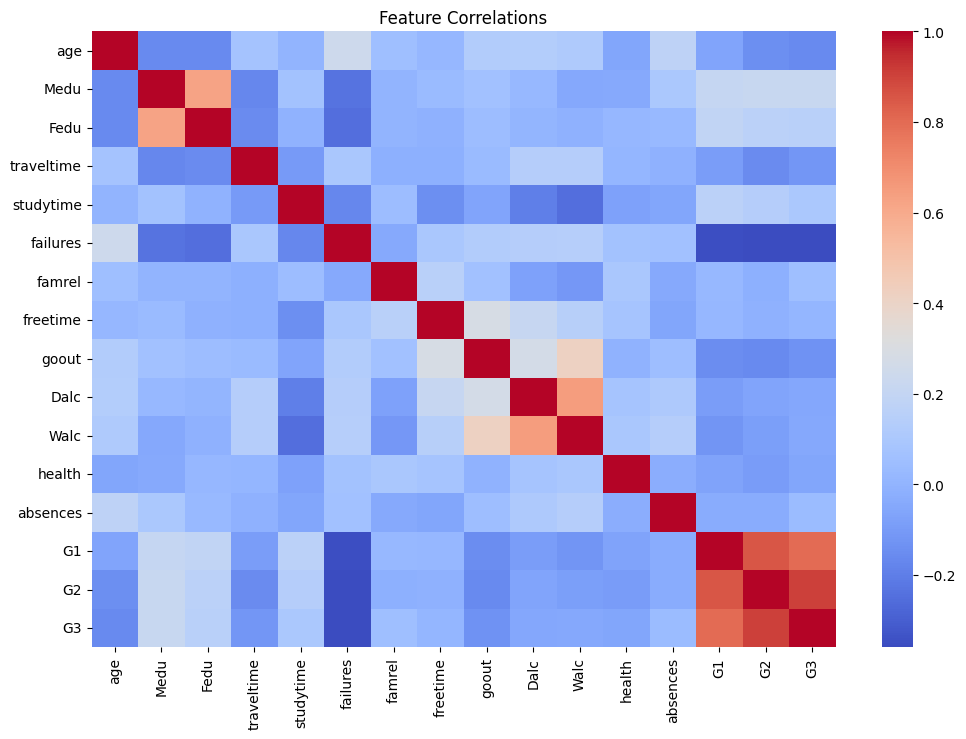

In [19]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlations")
plt.show()


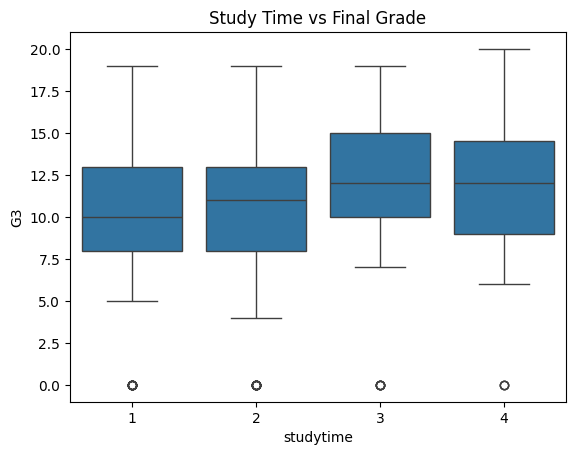

In [20]:
# Studytime vs G3
sns.boxplot(x='studytime', y='G3', data=df)
plt.title("Study Time vs Final Grade")
plt.show()

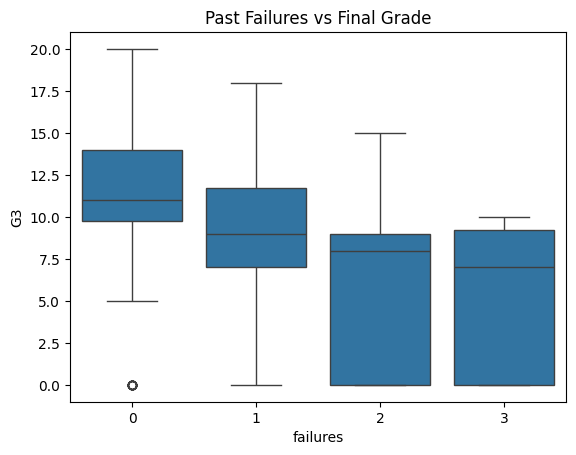

In [21]:
# Failures vs G3
sns.boxplot(x='failures', y='G3', data=df)
plt.title("Past Failures vs Final Grade")
plt.show()

In [22]:
#Preprocessing
# Separate features and target
X = df.drop('G3', axis=1)
y = df['G3']

# Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(316, 41) (79, 41)


In [23]:
#Train Multiple Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"MAE": round(mae, 2), "R2": round(r2, 2)}
    print(f"{name} → MAE: {mae:.2f} | R²: {r2:.2f}")

Linear Regression → MAE: 1.65 | R²: 0.72
Decision Tree → MAE: 1.14 | R²: 0.80
Random Forest → MAE: 1.16 | R²: 0.81


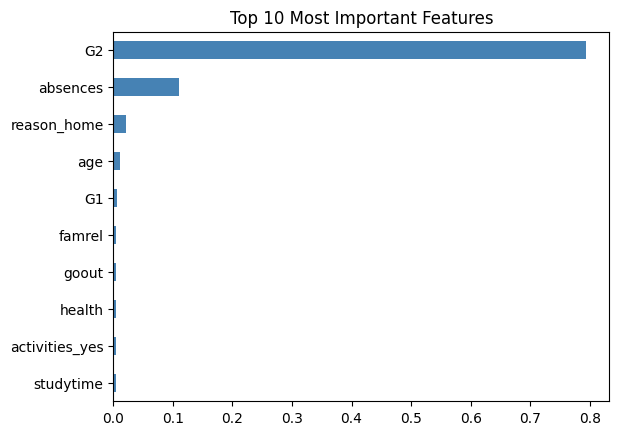

In [24]:
#Feature importance
rf_model = models["Random Forest"]

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='steelblue')
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

In [25]:
#Improve with Cross-Validation
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"Cross-validated R²: {scores.mean():.2f} ± {scores.std():.2f}")

Cross-validated R²: 0.83 ± 0.04


In [26]:
#Make a Prediction 
# Fit on full training data
rf.fit(X_train, y_train)

# Predict on one student
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = rf.predict(sample)
actual = y_test.iloc[0]

print(f"Predicted Grade: {prediction[0]:.1f}")
print(f"Actual Grade:    {actual}")

Predicted Grade: 8.3
Actual Grade:    10


C:\Users\emman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
